In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import datetime as dt
import re

In [2]:
# File paths
file_names = [r"data\firsttest_test_data_20251128_095740.csv",
              r"data\newdata_test_data_20251128_115950.csv",
              r"data\5blade_test_data_20251128_120814.csv",
              r"data\11blade_test_data_20251128_121726.csv",
              ]

In [3]:
# Useful functions
def datetime_conversion(timestamp):
    timestamp = timestamp[:-4]
    return dt.datetime.strptime(timestamp,'%Y-%m-%d %H:%M:%S')
def moving_average(data, window_size=5):
    """Calculate moving average of data"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [56]:
# Extraction of data
fan_results = []
flowcoeffs = []
flowcoeffs_errors = []
prisecoeffs = []
prisecoeffs_errors = []
avgSpeeds = []
dpventuris = []
dpventuris_errors = []
dpstages = []
dpstages_errors = []

times = pd.read_csv(file_names[0])['timestamp'].apply(datetime_conversion)
rel_times = (times - times.iloc[0]).dt.total_seconds()

for i, f in enumerate(file_names):
    fan_results.append(pd.read_csv(f))
    avgSpeeds.append(np.mean(fan_results[i]['rpm_mean']))

In [57]:
# Label generation regex
re_expression = r"([0-9]+blade)"
re_expression2 = r"(?<=data\\)([a-z0-9]+)(?=_test)"
labels = [re.search(re_expression2,f).group(0)+ f" (Avg RPM: {avgSpeeds[i]:.1f})" for i,f in enumerate(file_names)]

## Pressure Plot

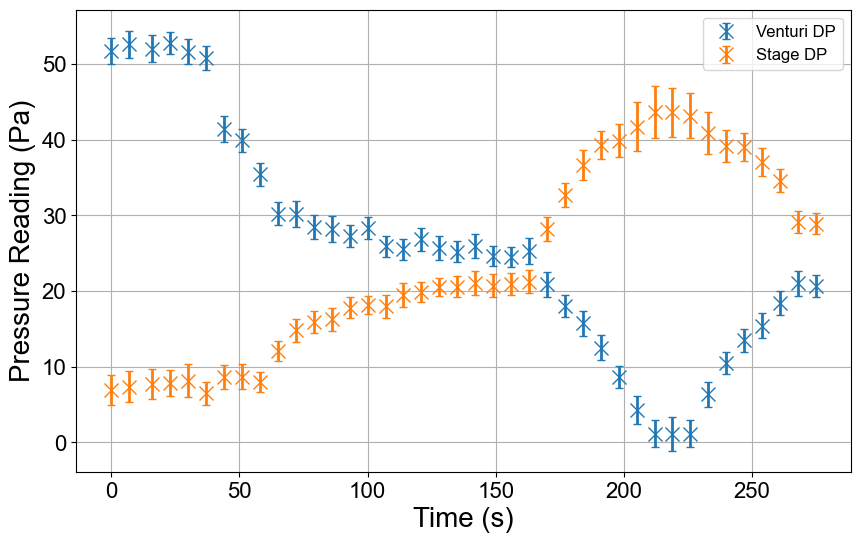

In [15]:
plt.style.use('presentation.mplstyle')
fig1,ax1 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    ax1.errorbar(rel_times, r['dp_venturi_mean'], yerr=r['dp_venturi_stddev'],label=f"Venturi DP", **errorbar_format)
    ax1.errorbar(rel_times, r['dp_stage_mean'], yerr=r['dp_stage_stddev'], label=f"Stage DP", **errorbar_format)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure Reading (Pa)")
ax1.legend()
ax1.grid()
fig1.savefig("presentation/pressure_readings.svg", bbox_inches='tight')
plt.show()

## Axial Velocity and Mass flow

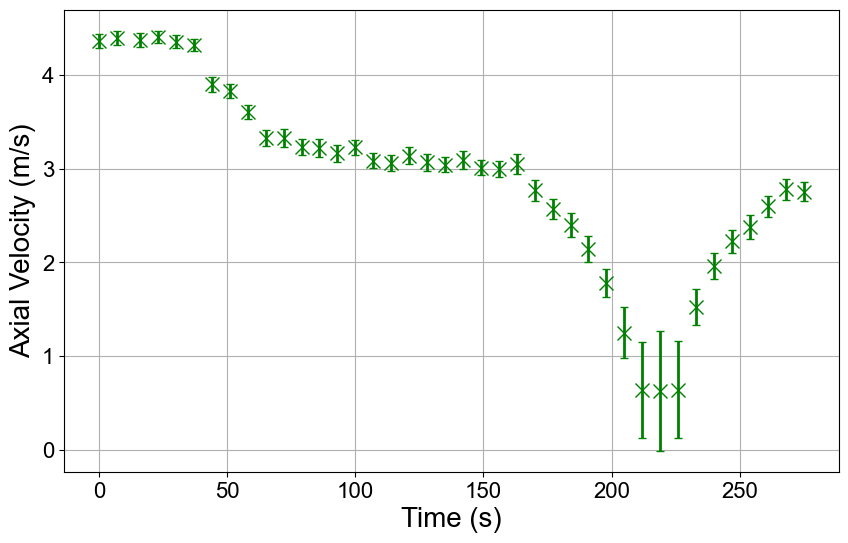

In [16]:
fig2,ax2 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    ax2.errorbar(rel_times, r['axvelocity_mean'], yerr=r['axvelocity_stddev'],label=f"Axial Velocity", color='g', **errorbar_format)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Axial Velocity (m/s)")
ax2.grid()
fig2.savefig("presentation/axial_velocity.svg", bbox_inches='tight')
plt.show()

## Flow Coeff vs Prise

In [28]:
# file_names = [r"data\5blade_test_data_20251128_123537.csv",
#               r"data\firsttest_test_data_20251128_095740.csv",
#               r"data\11blade_test_data_20251128_121726.csv",
#               ]
file_names = [
              r"data\firsttest_test_data_20251128_095740.csv",
              r"data\retest_test_data_20251128_100251.csv",
              r"data\rebuild_test_data_20251128_100917.csv",
              ]
# file_names = [
#               r"data\stall_test_data_20251128_124500.csv",
#               ]


In [29]:
fan_results = []
avgSpeeds = []
for i, f in enumerate(file_names):
    fan_results.append(pd.read_csv(f))
    avgSpeeds.append(np.mean(fan_results[i]['rpm_mean']))
    
# labels = ["5 Blade", "7 Blade", "11 Blade"]
labels = ["Test 1", "Test 2", "Test 3 (with rebuild)"]
# labels = ["stall 5 blade"]


In [30]:
# Calculation of 95% confidence intervals
for d in fan_results:
    d["flowcoeff_confidence"] = 1.96 * d['flow_coefficient_stddev'] / np.sqrt(100)
    d["prisecoeff_confidence"] = 1.96 * d['pressure_rise_coefficient_stddev'] / np.sqrt(100)

In [21]:
colours = ['b','r','g','c']

In [14]:
plt.style.use('presentation.mplstyle')

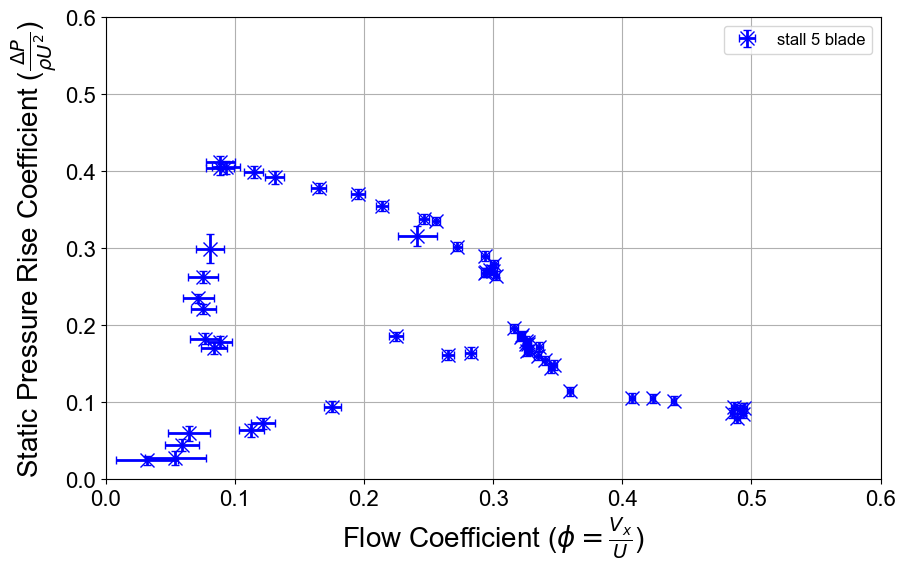

In [140]:
fig3,ax3 = plt.subplots(1,1,figsize=(10,6))
errorbar_format = {'fmt':'x','capsize':3}
for i, r in enumerate(fan_results):
    ax3.errorbar(r['flow_coefficient_mean'], 
                 r['pressure_rise_coefficient_mean'], 
                 xerr=r['flowcoeff_confidence'], 
                 yerr=r['prisecoeff_confidence'], 
                 color=colours[i], label = labels[i], **errorbar_format)
ax3.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax3.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)")
ax3.grid()
ax3.set_ylim(0,0.6)
ax3.set_xlim(0,0.6)
ax3.legend()
# fig3.savefig("presentation/repeat_fan_performance_curve.svg", bbox_inches='tight')
# fig3.savefig("presentation/fan_performance_curve_multi_fan.svg", bbox_inches='tight')
# fig3.savefig("presentation/repeat_confidence95_fan_performance_curve.svg", bbox_inches='tight')
plt.show()

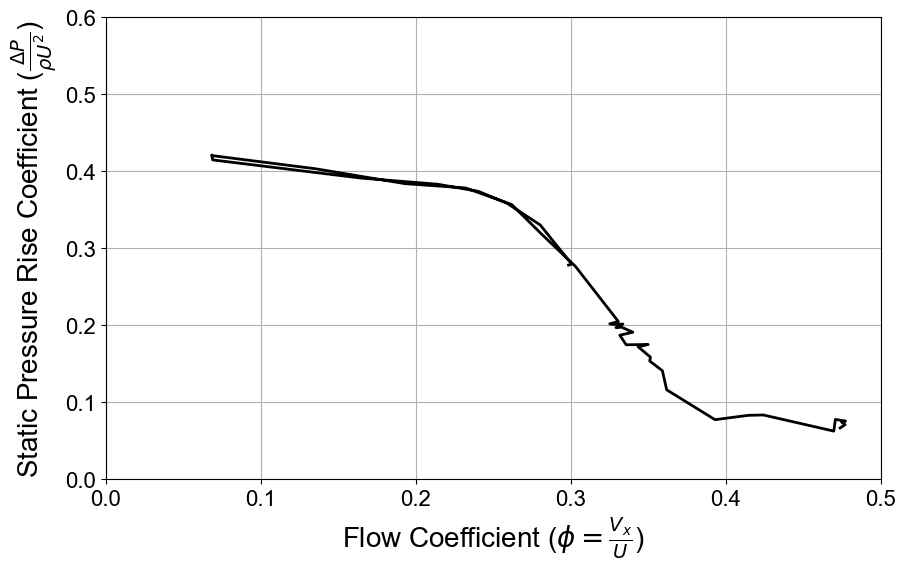

In [ ]:
fig4,ax4 = plt.subplots(1,1,figsize=(10,6))
for i, r in enumerate(fan_results):
    ax4.plot(fan_results[i]['flow_coefficient_mean'], fan_results[i]['pressure_rise_coefficient_mean'], color=colours[i],label = labels[i])
ax4.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)")
ax4.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)")
ax4.grid()
ax4.set_ylim(0,0.6)
ax4.set_xlim(0,0.5)
# ax4.legend()
# fig4.savefig("presentation/fan_performance_curve_line.svg", bbox_inches='tight')
plt.show()

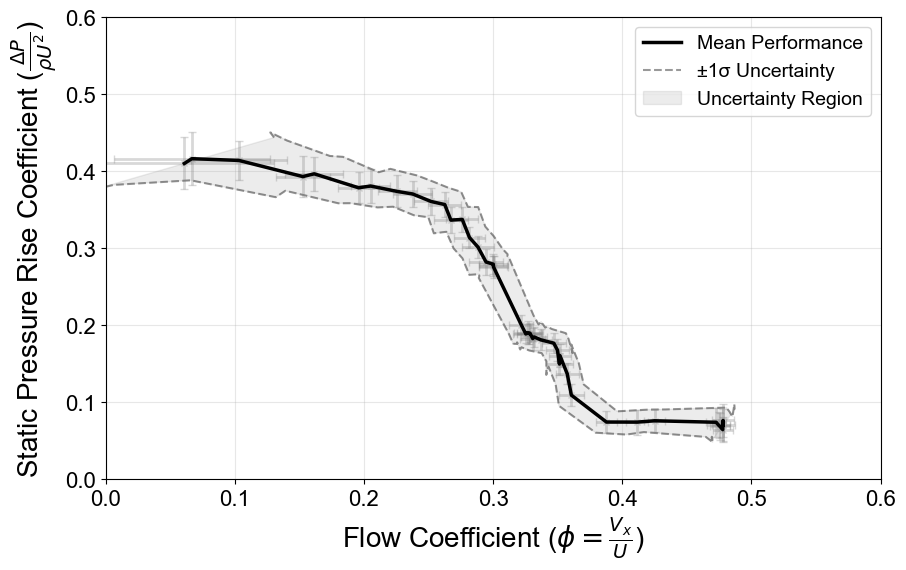

In [127]:
fig5, ax5 = plt.subplots(1, 1, figsize=(10, 6))

# Use the second dataset (retest) for detailed analysis
data = fan_results[1]

# Sort by flow coefficient
sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
prise_err_sorted = data['pressure_rise_coefficient_stddev'].values[sorted_indices]
flow_err_sorted = data['flow_coefficient_stddev'].values[sorted_indices]

# Plot main line
ax5.plot(flow_sorted, prise_sorted, 'k-', linewidth=2.5, label='Mean Performance', zorder=3)
#ax5.scatter(flow_sorted, prise_sorted,marker='x', color='k', label='Mean Performance')

# Create Pareto front envelope considering both x and y uncertainties
# Upper bound: (flow + flow_err, prise + prise_err)
# Lower bound: (flow - flow_err, prise - prise_err)
upper_flow = flow_sorted + flow_err_sorted
upper_prise = prise_sorted + prise_err_sorted
lower_flow = flow_sorted - flow_err_sorted
lower_prise = prise_sorted - prise_err_sorted

# Plot uncertainty envelope as dotted lines
ax5.plot(upper_flow, upper_prise, 'k--', alpha=0.4, linewidth=1.5, label='±1σ Uncertainty')
ax5.plot(lower_flow, lower_prise, 'k--', alpha=0.4, linewidth=1.5)

# Create filled region for the uncertainty envelope
# Combine upper and lower bounds into a closed polygon
flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
ax5.fill(flow_envelope, prise_envelope, alpha=0.15, color='gray', label='Uncertainty Region')

# Plot individual points with error bars for reference
ax5.errorbar(data['flow_coefficient_mean'], 
             data['pressure_rise_coefficient_mean'], 
             xerr=data['flow_coefficient_stddev'], 
             yerr=data['pressure_rise_coefficient_stddev'], 
             fmt='x', capsize=3, alpha=0.3, color='gray', markersize=5)

ax5.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax5.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax5.set_ylim(0, 0.6)
ax5.set_xlim(0, 0.6)
ax5.grid(alpha=0.3)
ax5.legend(fontsize=14)
fig5.savefig("presentation/fan_performance_with_uncertainty.svg", bbox_inches='tight')
plt.show()

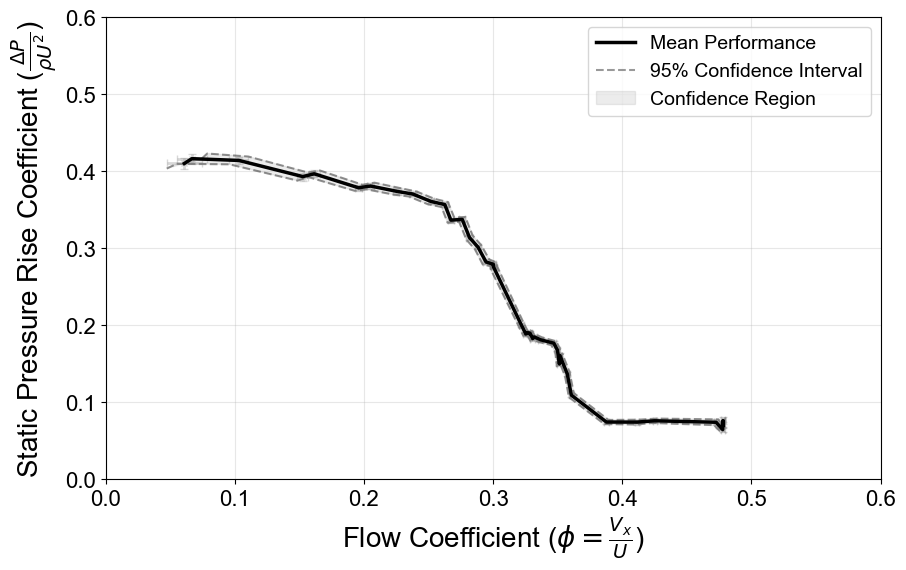

In [129]:
fig6, ax6 = plt.subplots(1, 1, figsize=(10, 6))

# Use the second dataset (retest) for detailed analysis
data = fan_results[1]

# Sort by flow coefficient
sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
prise_err_sorted = data['prisecoeff_confidence'].values[sorted_indices]
flow_err_sorted = data['flowcoeff_confidence'].values[sorted_indices]

# Plot main line
ax6.plot(flow_sorted, prise_sorted, 'k-', linewidth=2.5, label='Mean Performance', zorder=3)
#ax6.scatter(flow_sorted, prise_sorted,marker='x', color='k', label='Mean Performance')

# Create Pareto front envelope considering both x and y uncertainties
# Upper bound: (flow + flow_err, prise + prise_err)
# Lower bound: (flow - flow_err, prise - prise_err)
upper_flow = flow_sorted + flow_err_sorted
upper_prise = prise_sorted + prise_err_sorted
lower_flow = flow_sorted - flow_err_sorted
lower_prise = prise_sorted - prise_err_sorted

# Plot uncertainty envelope as dotted lines
ax6.plot(upper_flow, upper_prise, 'k--', alpha=0.4, linewidth=1.5, label='95% Confidence Interval')
ax6.plot(lower_flow, lower_prise, 'k--', alpha=0.4, linewidth=1.5)

# Create filled region for the uncertainty envelope
# Combine upper and lower bounds into a closed polygon
flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
ax6.fill(flow_envelope, prise_envelope, alpha=0.15, color='gray', label='Confidence Region')

# Plot individual points with error bars for reference
ax6.errorbar(data['flow_coefficient_mean'], 
             data['pressure_rise_coefficient_mean'], 
             xerr=data['flowcoeff_confidence'], 
             yerr=data['prisecoeff_confidence'], 
             fmt='x', capsize=3, alpha=0.3, color='gray', markersize=5)

ax6.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax6.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax6.set_ylim(0, 0.6)
ax6.set_xlim(0, 0.6)
ax6.grid(alpha=0.3)
ax6.legend(fontsize=14)
fig6.savefig("presentation/fan_performance_with_confidence95.svg", bbox_inches='tight')
plt.show()

## All Tests - Performance Curves with Uncertainty

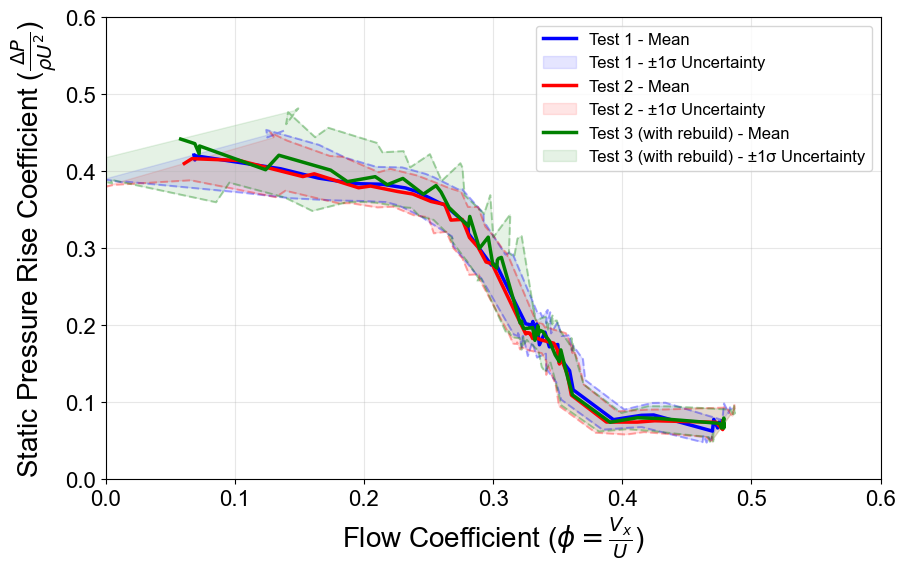

In [130]:
fig7, ax7 = plt.subplots(1, 1, figsize=(10, 6))

colours_all = ['b', 'r', 'g']

for idx, data in enumerate(fan_results):
    # Sort by flow coefficient
    sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
    flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
    prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
    prise_err_sorted = data['pressure_rise_coefficient_stddev'].values[sorted_indices]
    flow_err_sorted = data['flow_coefficient_stddev'].values[sorted_indices]
    
    # Plot main line
    ax7.plot(flow_sorted, prise_sorted, color=colours_all[idx], linewidth=2.5, label=f'{labels[idx]} - Mean', zorder=3)
    
    # Create Pareto front envelope considering both x and y uncertainties
    upper_flow = flow_sorted + flow_err_sorted
    upper_prise = prise_sorted + prise_err_sorted
    lower_flow = flow_sorted - flow_err_sorted
    lower_prise = prise_sorted - prise_err_sorted
    
    # Plot uncertainty envelope as dotted lines
    ax7.plot(upper_flow, upper_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    ax7.plot(lower_flow, lower_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    
    # Create filled region for the uncertainty envelope
    flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
    prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
    ax7.fill(flow_envelope, prise_envelope, alpha=0.1, color=colours_all[idx], label = f'{labels[idx]} - ±1σ Uncertainty')

ax7.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax7.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax7.set_ylim(0, 0.6)
ax7.set_xlim(0, 0.6)
ax7.grid(alpha=0.3)
ax7.legend(fontsize=12)
fig7.savefig("presentation/all_tests_performance_curves.svg", bbox_inches='tight')
plt.show()

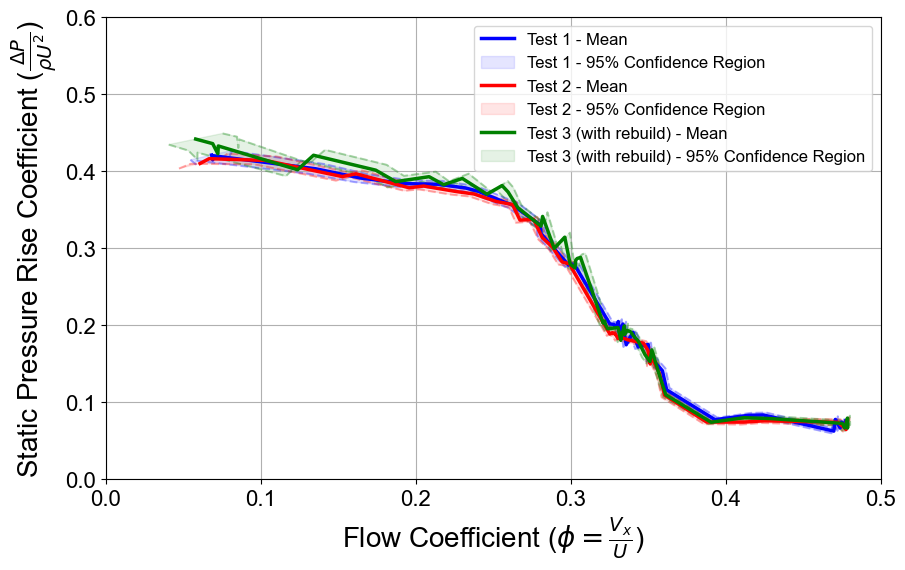

In [31]:
fig8, ax8 = plt.subplots(1, 1, figsize=(10, 6))

colours_all = ['b', 'r', 'g']

for idx, data in enumerate(fan_results):
    # Sort by flow coefficient
    sorted_indices = np.argsort(data['flow_coefficient_mean'].values)
    flow_sorted = data['flow_coefficient_mean'].values[sorted_indices]
    prise_sorted = data['pressure_rise_coefficient_mean'].values[sorted_indices]
    prise_err_sorted = data['prisecoeff_confidence'].values[sorted_indices]
    flow_err_sorted = data['flowcoeff_confidence'].values[sorted_indices]
    
    # Plot main line
    ax8.plot(flow_sorted, prise_sorted, color=colours_all[idx], linewidth=2.5, label=f'{labels[idx]} - Mean', zorder=3)
    # ax8.scatter(flow_sorted, prise_sorted, color=colours_all[idx], marker='x', label=f'{labels[idx]} - Mean')
    
    # Create Pareto front envelope considering both x and y uncertainties
    upper_flow = flow_sorted + flow_err_sorted
    upper_prise = prise_sorted + prise_err_sorted
    lower_flow = flow_sorted - flow_err_sorted
    lower_prise = prise_sorted - prise_err_sorted
    
    # Plot uncertainty envelope as dotted lines
    ax8.plot(upper_flow, upper_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    ax8.plot(lower_flow, lower_prise, '--', alpha=0.3, linewidth=1.5, color=colours_all[idx])
    
    # Create filled region for the uncertainty envelope
    flow_envelope = np.concatenate([upper_flow, lower_flow[::-1]])
    prise_envelope = np.concatenate([upper_prise, lower_prise[::-1]])
    ax8.fill(flow_envelope, prise_envelope, alpha=0.1, color=colours_all[idx], label = f'{labels[idx]} - 95% Confidence Region')

ax8.set_xlabel("Flow Coefficient ($\\phi = \\frac{V_x}{U}$)", fontsize=20)
ax8.set_ylabel("Static Pressure Rise Coefficient ($\\frac{\\Delta P}{\\rho U^2}$)", fontsize=20)
ax8.set_ylim(0, 0.6)
ax8.set_xlim(0, 0.5)
ax8.grid()
ax8.legend()
fig8.savefig("presentation/all_tests_performance_curves_95confidence_3test.svg", bbox_inches='tight')
plt.show()